**Simulations:** functions

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1/(1 + np.exp(-x))


def symmetrize(A):
    return 0.5 * (A + A.T)

def sample_mvn(mean, cov, n, rng, jitter=1e-10): # campiona punti da una distribuzione normale multivariata
    cov = symmetrize(cov) + jitter * np.eye(cov.shape[0]) # jitter aggiunto alla diagonale serve a garantire la pos def
    return rng.multivariate_normal(mean, cov, size=n)  # n indica quanti campioni generare dalla distribuzione


#   -------------------------------------------
# 0) FUNZIONI PER CAMPIONARE VARIANZE ALEATORIE
#   -------------------------------------------
# Varianze Gamma

def make_sample_V_gamma_function(lam_val):

    def sample_V_gamma_inner(layer, size, rng, n0):
        if layer == 0:
            # For layer 0, using 1/n0 as a common choice for input variances.
            return np.ones(size) / n0
        else:
            # For layer > 0, sample from Gamma(shape=1/size, scale=lam)
            # where 'size' corresponds to n_ell and 'lam' is the rate parameter.
            # Assuming 'lam_val' is the rate parameter (beta), the scale parameter for numpy is 1/beta.
            return rng.gamma(shape=1.0 / size, scale=1.0 / lam_val, size=size)
    return sample_V_gamma_inner

# Default lam value
lam = 3.0
sample_V_gamma = make_sample_V_gamma_function(lam)

# per cambiare: sample_V_gamma = make_sample_V_gamma(lam=*)



# Varianze fisse a 1/n_ell (caso gaussiano)

def sample_V_const(layer, size, rng, n0):
    if layer == 0:
        # For layer 0, using 1/n0 as a common choice for input variances.
        return np.ones(size) / n0
    else:
        # For layer > 0, fixed variance to 1.0, adjusted to 1/size as per request
        return np.ones(size) / size



# Varianze i.i.d.:   X_j/n_ell, X_j esponenziali
def make_sample_V_exp(rate):

    scale = 1.0 / rate # For numpy's exponential distribution, scale = 1/lambda (rate)

    def sample_V_exp_inner(layer, size, rng, n0):
        if layer == 0:
            # For layer 0, using 1/n0 as a common choice for input variances.
            return np.ones(size) / n0
        else:
            # For layer > 0, sample X_j from Exp(rate) and divide by size (n_ell)
            X_j_samples = rng.exponential(scale=scale, size=size)
            return X_j_samples / size
    return sample_V_exp_inner

# Example usage for Exp(2) variances
sample_V_iid_exp = make_sample_V_exp(rate=2.0)






# ----------------------------------
# 1) Simulazione di UNA rete finita
# ----------------------------------
def simulate_one_network(
        X,
        L,
        widths,
        output_width,
        sample_V,
        sigma,
        C_B,
        C_W,
        rng=None):
    """
    Simula una realizzazione della rete con L livelli nascosti, larghezze variabili, con d inputs

    Parameters
    ----------
    X : array, shape (n0,d)
        Matrice di input:  x^(1), ..., x^(d)
    L : Numero di livelli nascosti.
    widths : list or tuple
        Larghezze dei livelli nascosti: [n_1, n_2, ..., n_L].
    output_width : int
        Larghezza del livello di output (n_{L+1}).
    sample_V : funzione per campionare le varianze aleatorie.
    sigma : Funzione di attivazione.
    C_B, C_W : varianze dei parametri
    rng : np.random.Generator

    Returns
    -------
    Z_final : array, shape (n_L+1,d) or (d,)
        Output finale della rete per ciascun input.
        Se n_L+1 è 1, restituisce (d,).
        Altrimenti, restituisce (n_L+1,d).
    """
    rng = np.random.default_rng() if rng is None else rng
    X = np.asarray(X, dtype=float)

    n0, d = X.shape

    if len(widths) != L:
        raise ValueError(f"widths must have length L ({L}), but got {len(widths)}.")

    current_activations = X.copy() # Shape: (n0, d)

    # Layer 0 Variances (V^(0))
    V_prev = np.asarray(sample_V(0, n0, rng, n0=n0), dtype=float).reshape(-1)
    if V_prev.size != n0:
        raise ValueError(f"sample_V(layer=0, ...) returned size {V_prev.size}, expected {n0}.")

    current_layer_dim=n0


    # Simulate Hidden Layers (1 to L)
    for ell_idx in range(L): # ell_idx runs from 0 to L-1 (index of the hidden layer)
        ell = ell_idx + 1 # Actual layer number (1 to L)
        next_layer_dim = widths[ell_idx]  # Width of the hidden layer (n_ell)
                                          # RMK: widths= [n_1, n_2, ..., n_L] !

        # H_prev are the outputs of the previous layer's activation
        H_prev = sigma(current_activations) if ell_idx > 0 else current_activations

        # Biases B_j^(ell) ~ N(0, C_B)
        B = rng.normal(loc=0.0, scale=np.sqrt(C_B), size=next_layer_dim)

        # N_jk^(ell) ~ N(0, C_W)
        N = rng.normal(loc=0.0, scale=np.sqrt(C_W), size=(next_layer_dim, current_layer_dim))

        # W_jk^(ell) = sqrt(V_k^(ell-1)) * N_jk^(ell)
        W = N * np.sqrt(V_prev)[None, :]  # W has shape (next_layer_dim, current_layer_dim)=(n_l,n_l-1)

        # Z_curr_activations will have shape (next_layer_dim, d)
        current_activations = B[:, None] + W @ H_prev

        # Update V_prev for the next layer (V^(ell))
        V_prev = np.asarray(sample_V(ell, next_layer_dim, rng, n0=n0), dtype=float).reshape(-1)
        if V_prev.size != next_layer_dim:
            raise ValueError(f"sample_V(layer={ell}, ...) returned size {V_prev.size}, expected {next_layer_dim}.")

        current_layer_dim = next_layer_dim


    # Output Layer (L+1)
    # H_L are the outputs of the last hidden layer's activation (from Z^(L))
    H_L = sigma(current_activations)

    B_out = rng.normal(loc=0.0, scale=np.sqrt(C_B), size=output_width)
    N_out = rng.normal(loc=0.0, scale=np.sqrt(C_W), size=(output_width, current_layer_dim))
    W_out = N_out * np.sqrt(V_prev)[None, :] # V_prev is now V^(L)

    Z_final = B_out[:, None] + W_out @ H_L # shape (n_L+1,d)

    # If output_width == 1, return a flat array
    if output_width == 1:
        return Z_final[0] # Returns shape (d,)
    else:
        return Z_final # Returns shape (n_L+1,d)





# ----------------------
# 2) CALCOLO K^(L+1)(x)
# ----------------------

# Esempio 1:

def sample_truncated_poisson_points_gamma_levy(lam, eps, rng):  # obiettivo : campionare da un PP con intensità rho(x) = exp(-lam * x) / x per x > eps
    """
    Simula i punti del PP con intensità rho(x)=exp(-lam x)/x su (eps, +inf) usando thinning
    """
    M = np.exp(-lam * eps) / (lam * eps)  # è il limite superiore della mis di levy
    N_star = rng.poisson(M) # si campiona N_star, il numero di punti da generare dalla distribuzione proposta,
                            # utilizzando una distribuzione di Poisson con parametro M.
                            # questi candidati verranno poi "assottigliati" (thinning)

    if N_star == 0:
        return np.empty(0)

    # proposal q_eps(x) = lam * exp(-lam (x-eps)), x >= eps
    Y = eps + rng.exponential(scale=1.0 / lam, size=N_star) #Vengono generati N_star punti candidati Y dalla distribuzione proposta q_eps(x)

    # acceptance probability = eps / Y
    U = rng.uniform(size=N_star)
    T = Y[U < (eps / Y)]
    # Per ogni punto candidato Y_i generato dalla distribuzione proposta, si calcola una probabilità di accettazione.
    # In questo caso, la probabilità di accettazione è data da eps / Y_i.
    # Viene poi generato un numero casuale U_i uniformemente distribuito tra 0 e 1. Se U_i < (eps / Y_i), allora il punto Y_i
    # viene accettato e incluso nell'insieme finale T. Altrimenti, viene rigettato.

    return T



def recursive_kernel_gamma_levy(
    X,
    L,
    C_B,
    C_W,
    lam,
    sigma,
    eps=1e-5,
    jitter=1e-10,
    rng=None
):
    """
    Calcola una realizzazione di K^{(L+1)} per il caso:
        rho(dx) = exp(-lam x)/x dx
    con a^(ell) = 0.

    Parameters
    ----------
    X : array, shape (n0,d)
        Input  x^(1), ..., x^(d).
    L : int
        Profondità della rete.
    C_B, C_W : float
        Costanti del kernel.
    sigma : Attivazione, vettorializzata.
    lam : float
        Parametro della misura di Lévy.
    eps : float
        Troncamento vicino a 0.
    jitter : float
        Regolarizzazione numerica della covarianza.
    rng : np.random.Generator
        Generatore casuale.

    Returns
    -------
    K : array, shape (d, d)
        K^(L+1).
    """
    rng = np.random.default_rng() if rng is None else rng
    X = np.asarray(X)
    n0, d = X.shape

    ones = np.ones((d, d))

    # livello 1
    K = C_B * ones + C_W * (X.T @ X) / n0
    K = symmetrize(K)

    # livelli 2,...,L+1
    for ell in range(2, L + 2):
       # punti Poisson troncati
       T = sample_truncated_poisson_points_gamma_levy(lam, eps, rng)
       K_new = C_B * ones.copy()

       if T.size > 0:
          cov = K + jitter * np.eye(d)
          Z = rng.multivariate_normal(mean=np.zeros(d), cov=cov, size=T.size) # Z is an array of shape (T.size, d)

          # sigma applicata riga per riga
          S = sigma(Z) #S is an array of shape (T.size, d), where each row s is sigma(z_i) for a sampled z_i from Z

          for t, s in zip(T, S):
              K_new += C_W * t * np.outer(s, s)
       K = symmetrize(K_new)

    return K



# caso rho=0
def K_no_poisson(
    X,
    L,
    C_B,
    C_W,
    a_list,
    sigma,
    n_mc,
    rng=None,
    jitter=1e-12
):
    """
    Calcola una stima Monte Carlo di K^{(L+1)} nel caso rho = 0.

    K^{(1)} = C_B * 11^T + C_W * X^T X / n0
    K^{(ell)} = C_B * 11^T + C_W * a_{ell-1} * E[sigma(z)sigma(z)^T]
    """
    rng = np.random.default_rng() if rng is None else rng
    X = np.asarray(X, dtype=float)
    n0, d = X.shape

    if L == 0:
        K = C_B * np.ones((d, d)) + C_W * (X.T @ X) / n0
        return symmetrize(K), [symmetrize(K)]

    if len(a_list) < L:
        raise ValueError(f"a_list must have length at least L={L}.")

    # K^(1)
    K = C_B * np.ones((d, d)) + C_W * (X.T @ X) / n0
    K = symmetrize(K)
    Ks = [K]

    # K^(2), ..., K^(L+1)
    for ell in range(2, L + 2):
        K_prev = Ks[-1]
        a_prev = float(a_list[ell - 2])  # E[X_1^(ell-1)]

        cov = symmetrize(K_prev) + jitter * np.eye(d)

        Z = rng.multivariate_normal(
            mean=np.zeros(d),
            cov=cov,
            size=n_mc
        )

        S = sigma(Z)  # shape (n_mc, d)
        E_term = (S.T @ S) / n_mc

        K_new = C_B * np.ones((d, d)) + C_W * a_prev * E_term
        K_new = symmetrize(K_new)
        Ks.append(K_new)

    return Ks[-1], Ks





# -----------------------
# Funzioni SIMULAZIONE 1
# -----------------------

def extract_scalar_output(Z_final, input_idx, output_idx): # input_idx -> seleziona il vettore input
                                                           # output_idx -> seleziona il neurone
    """
    Estrae z_i^(L+1)(x^(1)) da ciò che restituisce simulate_one_network.

    Caso 1: output_width = 1 -> Z_final può essere shape (d,)
    Caso 2: output_width > 1 -> Z_final può essere shape (output_width, d)
    """
    Z_final = np.asarray(Z_final)

    if Z_final.ndim == 1:
        # shape (d,)
        return float(Z_final[input_idx])
    elif Z_final.ndim == 2:
        # shape (output_width, d)
        return float(Z_final[output_idx, input_idx])
    else:
        raise ValueError(f"Unexpected shape for Z_final: {Z_final.shape}")



# funzione per calcolare PDF, CDF gaussiane del limite teorico

def get_gaussian_pdf_cdf_data(
    K,
    input_idx,
    mean=0.0, # defaults 0.0
    num_std_devs=4, # Range for x-axis in terms of standard deviations,
    num_points=500,
):
    """
    Calculates the PDF and CDF values for a 1D Gaussian distribution based on a covariance matrix K

    Parameters
    ----------
    K : np.ndarray
        The covariance matrix. The variance for the 1D Gaussian is taken from K[input_idx, input_idx].
    input_idx : int
        The index of the input/output dimension for which to extract the variance from K.
    mean : float, optional
        The mean of the Gaussian distribution.
    num_std_devs : int, optional
        The number of standard deviations from the mean to span on the x-axis for calculation. Defaults to 4.
    num_points : int, optional
        The number of points to use for generating the curves. Defaults to 500.

    Returns
    -------
    x : np.ndarray
        Array of x-values.
    pdf_values : np.ndarray
        Array of PDF values corresponding to x.
    cdf_values : np.ndarray
        Array of CDF values corresponding to x.
    """
    variance = K[input_idx, input_idx]
    if variance < 0:
        raise ValueError(f"Variance for input_idx {input_idx} is negative: {variance}")
    std_dev = np.sqrt(variance)

    if std_dev == 0:
        print(f"Warning: Standard deviation is zero for input_idx {input_idx}. Cannot calculate continuous Gaussian.")
        return np.empty(0), np.empty(0), np.empty(0)

    # Generate x-values for plotting
    x_min = mean - num_std_devs * std_dev
    x_max = mean + num_std_devs * std_dev
    x = np.linspace(x_min, x_max, num_points)

    # Calculate PDF and CDF values
    pdf_values = norm.pdf(x, loc=mean, scale=std_dev)
    cdf_values = norm.cdf(x, loc=mean, scale=std_dev)

    return x, pdf_values, cdf_values




# funzioni per generare la mistura gaussiana

def estimate_mixture_cdf(
    x_grid,
    M,
    X,
    L,
    C_B,
    C_W,
    lam,
    sigma,
    eps=1e-5,
    jitter=1e-10,
    input_idx=0,
    mean=0.0,
    rng=None,
):
    """
    Stima la CDF della mistura usando la CDF gaussiana condizionata esatta:

        F(x) =  E_K[ P(G <= x | K) ] = E_K[ Phi((x-mean)/sqrt(K)) ]

       Parametri
    ---------
    x_grid : array-like
        Punti su cui valutare la CDF.
    M : int
        Numero di campioni.

    X, L, C_B, C_W, lam, sigma, eps, jitter: as before

    input_idx : int
        Indice della diagonale di K da usare come varianza marginale.
    mean : float
        Media della gaussiana condizionata.
    rng : np.random.Generator, opzionale

    Returns
    -------
    cdf_est : np.ndarray
        Stima della CDF su x_grid.
    cdf_se : np.ndarray
        Errore standard stimato sui campioni esterni.
    variances : np.ndarray
        Varianze stimate per i M campioni.
    """
    rng = np.random.default_rng() if rng is None else rng
    x_grid = np.asarray(x_grid, dtype=float)

    outer_cdfs = np.zeros((M, len(x_grid)), dtype=float)
    variances = np.zeros(M, dtype=float)

    for m in range(M):
        rng_m = np.random.default_rng(rng.integers(0, 2**32 - 1)) # per simulazioni indipendenti
        K_m = recursive_kernel_gamma_levy(
            X=X,
            L=L,
            C_B=C_B,
            C_W=C_W,
            sigma=sigma,
            lam=lam,
            eps=eps,
            jitter=jitter,
            rng=rng_m
        )

        var_m = float(K_m[input_idx, input_idx])
        var_m = max(var_m, 1e-12)
        variances[m] = var_m
        std_m = np.sqrt(var_m)

        outer_cdfs[m, :] = norm.cdf((x_grid - mean) / std_m) # calcolo le CDF condizionate per tutti gli M campioni di K

    cdf_est = outer_cdfs.mean(axis=0)  # stima di E_K[Phi((x-mean)/sqrt(K))]
    cdf_se = outer_cdfs.std(axis=0, ddof=1) / np.sqrt(M) if M > 1 else np.zeros_like(cdf_est)
    return cdf_est, cdf_se, variances






# -----------------------
# Funzioni SIMULAZIONE 2
# -----------------------

# 1) simulazione traiettorie della rete per widths crescenti

def simulate_many_scalar_trajectories(
    x_grid,
    N,
    L,
    widths,
    sample_V,
    sigma,
    C_B,
    C_W,
    master_seed
):
    rng_master = np.random.default_rng(master_seed)
    X = np.asarray(x_grid, dtype=float).reshape(1, -1)  # now shape(X)=(1,d)

    trajectories = []
    for _ in range(N):
        rng_net = np.random.default_rng(rng_master.integers(0, 2**32 - 1))
        z = simulate_one_network(
            X=X,
            L=L,
            widths=widths,
            output_width=1, # stiamo considerando solo nL+1=1 per una questione di esposizione
            sample_V=sample_V,
            sigma=sigma,
            C_B=C_B,
            C_W=C_W,
            rng=rng_net
        )

        trajectories.append(np.asarray(z, dtype=float))  # shape (d,)

    return np.asarray(trajectories)






# 2) trajectories of the limit Gaussian mixture process

def sample_gp_from_random_kernel(times, X, L, C_B, C_W, lam, sigma,
                                 rng, eps=1e-5, jitter=1e-10 ):
    """
    Simula una traiettoria del processo limite:
        1) campiona K random
        2) campiona f | K ~ N(0, K)
    """
    rng = np.random.default_rng() if rng is None else rng

    # 1) realizza il kernel casuale sulla griglia
    K = recursive_kernel_gamma_levy(
        X=X, L=L, C_B=C_B, C_W=C_W, lam=lam, sigma=sigma,
        eps=eps, jitter=jitter, rng=rng
    )
    K = symmetrize(K)

    # 2) stabilizzazione numerica
    n = K.shape[0]
    K = K + jitter * np.eye(n)

    # 3) campiona f | K
    try:
        Lchol = np.linalg.cholesky(K)
        z = rng.standard_normal(n)
        path = Lchol @ z
    except np.linalg.LinAlgError:
        # fallback robusto se Cholesky fallisce
        vals, vecs = np.linalg.eigh(K)
        vals = np.clip(vals, 1e-12, None) #  Negative or very small eigenvalues are clipped to a small positive value
                                          #  (1e-12) to ensure stability when taking the square root.
        path = vecs @ (np.sqrt(vals) * rng.standard_normal(n)) # alternative way to sample from a multivariate normal distribution.
                                                               # It projects independent standard normal variables
                                                               # onto the principal directions scaled by the square root of the eigenvalues

    return path, K

def sample_many_paths(M, times, X, L, C_B, C_W, lam, sigma, rng,
                      eps=1e-5, jitter=1e-10
                      ):
    rng = np.random.default_rng() if rng is None else rng

    paths = []
    kernels = []

    for _ in range(M):
        path, K = sample_gp_from_random_kernel(
            times, X, L, C_B, C_W, lam, sigma,
            eps=eps, jitter=jitter, rng=rng
        )
        paths.append(path)
        kernels.append(K)

    return np.asarray(paths), kernels





# -----------------------
# Funzioni SIMULAZIONE 3
# -----------------------
def hs_norm(M):
    """Hilbert–Schmidt / Frobenius norm."""
    M = np.asarray(M, dtype=float)
    return np.linalg.norm(M, ord="fro")


def simulate_last_layer_state(
    X,
    L,
    widths,
    C_B,
    C_W,
    sample_V,
    sigma,
    rng=None,
):
    """Simulates only the final state necessary for A^{(L+1)}:
      - S = sigma(z^{(L)}) if L >= 1
      - S = X if L = 0
      - V_L = V^{(L)}

    Returns
    -------
    S : array, shape (n_L, d) if L>=1, otherwise (n0, d)
    V_L : array, shape (n_L,) if L>=1, otherwise (n0,)
    """
    rng = np.random.default_rng() if rng is None else rng
    X = np.asarray(X, dtype=float)

    n0, d = X.shape
    if len(widths) != L:
        raise ValueError("widths must have length L, i.e. [n1, ..., nL].")

    # Case L=0: no hidden layer, explicit formula
    if L == 0:
        V_L = sample_V(layer=0, size=n0, rng=rng, n0=n0)
        S = X
        return S, V_L

    # V^(0)
    V_prev = sample_V(layer=0, size=n0, rng=rng, n0=n0)

    current_activations = X  # fictitious z^(0) = input
    current_dim = n0

    # Hidden Layers 1,...,L
    for ell_idx in range(L):
        ell = ell_idx + 1
        next_dim = widths[ell_idx]

        # First hidden layer uses X directly, others use sigma(z)
        H_prev = current_activations if ell_idx == 0 else sigma(current_activations)

        B = rng.normal(loc=0.0, scale=np.sqrt(C_B), size=next_dim)
        N = rng.normal(loc=0.0, scale=np.sqrt(C_W), size=(next_dim, current_dim))
        W = N * np.sqrt(V_prev)[None, :]

        current_activations = B[:, None] + W @ H_prev
        current_dim = next_dim

        # Prepares V^(ell) only if needed for the next layer
        if ell < L:
            V_prev = sample_V(layer=ell,size=next_dim,rng=rng,n0=n0)

    # Last level: V^(L) and final activations
    V_L = sample_V(layer=L, size=current_dim, rng=rng, n0=n0)
    S = sigma(current_activations)

    return S, V_L


def A_L_plus_1(
    X,
    L,
    C_B,
    C_W,
    sample_V,
    widths,
    sigma,
    rng=None,
):
    """Simulates a realization of A^{(L+1)}.

    Formula:
      A = C_B * 11^T + C_W * S^T diag(V_L) S
    with:
      S = sigma(z^{(L)}) if L>=1
      S = X if L=0
    """
    X = np.asarray(X, dtype=float)
    n0, d = X.shape

    S, V_L = simulate_last_layer_state(
        X=X,
        L=L,
        widths=widths,
        C_B=C_B,
        C_W=C_W,
        sample_V=sample_V,
        sigma=sigma,
        rng=rng,
    )

    A_c = C_W * (S.T @ (V_L[:, None] * S))
    A = C_B * np.ones((d, d)) + A_c
    return symmetrize(A)


def estimate_hs_terms(
    X,
    widths_list,
    L,
    C_B,
    C_W,
    sample_V,
    a_list,
    sigma,
    A_L_plus_1,
    K_no_poisson,
    n_reps,
    n_mc_K,
    output_width=1,
    seed=1234,
    jitter_K=1e-12,
    K_true=None,
):
    """Empirically estimates, for each width p, the HS terms of the bound:
        (E[||A-K||_HS^8])^(1/4)
    """
    rng_master = np.random.default_rng(seed)
    X = np.asarray(X, dtype=float)
    n0, d = X.shape
    J = np.ones((d, d))

    # Theoretical Kernel (or externally provided)
    if K_true is None:
        rng_K = np.random.default_rng(int(rng_master.integers(0, 2**63 - 1)))
        K_true, _ = K_no_poisson(
            X=X,
            L=L,
            C_B=C_B,
            C_W=C_W,
            sigma=sigma,
            a_list=a_list,
            n_mc=n_mc_K,
            rng=rng_K,
            jitter=jitter_K,
        )

    K_true = symmetrize(np.asarray(K_true, dtype=float))

    # Centered formula because the bias should cancel out
    K_c = K_true - C_B * J

    results = {}

    for p in widths_list:
        widths = [p] * L

        A_sum_c = np.zeros((d, d), dtype=float)
        hs8_sum = 0.0
        hs_diffs = []

        # independent seeds for each replica
        rep_seeds = rng_master.integers(0, 2**63 - 1, size=n_reps, dtype=np.int64)

        for rs in rep_seeds:
            rng_rep = np.random.default_rng(int(rs))

            A = A_L_plus_1(
                X=X,
                L=L,
                C_B=C_B,
                C_W=C_W,
                sample_V=sample_V,
                widths=widths,
                sigma=sigma,
                rng=rng_rep,
            )
            A = symmetrize(np.asarray(A, dtype=float))

            # trying to consider centered matrices, as the C_B term should cancel out
            A_c = A - C_B * J
            D = A_c - K_c

            diff_hs = hs_norm(D)
            hs_diffs.append(diff_hs)
            hs8_sum += diff_hs ** 8

        term2 = output_width * (hs8_sum / n_reps) ** 0.25

        results[p] = {
            "term2": term2,
            "hs_diffs": np.asarray(hs_diffs),
            "K_true": K_true,
            "K_centered": K_c,
        }

    return K_true, results

**SIMULATION 1**: empirical validation of the large-width, finite-dimensional CLT with random variances

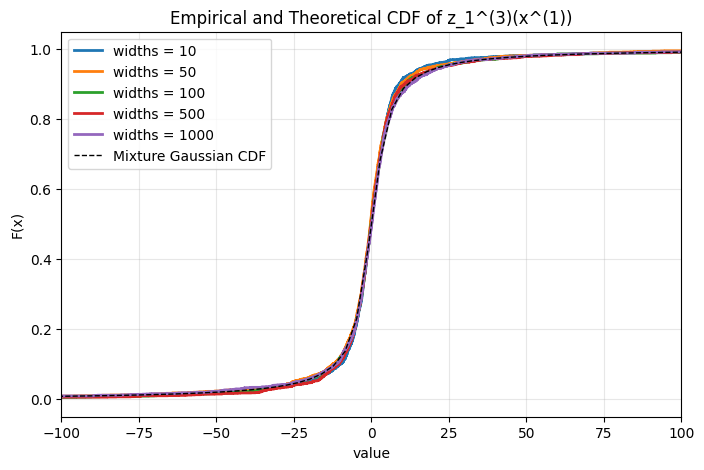

In [ ]:
# Theorem ** (Lee et al):
# Assuming we are working with random variances, given {x^(1),...,x^{(d)}} inputs, x:=(x^(1),...,x^(d)),
# lim_{n_L -> infty}... lim_{n_1 -> infty} Z^(L+1)(x)=H^(L+1)(x)
# dove H^(L+1)(x) ~ GM_{n_(L+1)d}(0,I_n_(L+1) o K^(L+1)(x))
# and K^(L+1)(x) is recursively defined stochastically

# we empirically verify this convergence. In detail, Z^(L+1)(x)=(z_1^(L+1)(x),...,z_(n_L+1)^(L+1)(x)),
# dove z_i^(L+1)(x):=(z_i^(L+1)(x^(1)),...,z_i^(L+1)(x^(d))).

# We work with the following hypotheses:
# L=2
# n0=4
# n3=1
# d=3
# sigma=relu

# in particular, n3=1 implies Z^(L+1)(x)=z_1^(3)(x)=(z_1^3(x^(1)),...,z_1^3(x^(d)))! Much simpler.
# We therefore study what happens to the marginals of this vector, in particular to the first component: z_1^3(x^(1)).

# We previously defined simulate_one_network, the function that simulates the network output.
# In detail, this function returns Z_n_L^(L+1)(x), which is n_L x d,
# while we would like z_i^(L+1)(x). The following function simulates z_1^3(x^(1))




# ----------------------------------------------------------
# EXAMPLE WITH Gamma VARIANCES : V_{n_l,j} ~ Gamma(1/n_l, lam)
# ----------------------------------------------------------
# We generate THEORETICAL AND EMPIRICAL PDF, CDFs

X = np.array(
    [[0.2, -0.1, 0.4],
     [1.0,  0.3, 0.7],
     [-0.5, 0.8, 0.1],
     [0.9, -0.2, 0.6]], dtype=float)

p_list = [10, 50, 100, 500, 1000]

n_reps = 2000

lam = 3
sample_V_gamma = make_sample_V_gamma_function(lam)

C_B = 10
C_W = 15
L = 5
n_L_plus_1 = 1
# n0_val = X.shape[0]

rng = np.random.default_rng(42)

# 1. Collect Empirical Outputs
outputs_by_width = {}
for p in p_list:
    samples = np.zeros(n_reps, dtype=float)
    for r in range(n_reps):
        Z_final = simulate_one_network(
            X=X,
            L=L,
            C_B=C_B,
            C_W=C_W,
            widths=[int(p - (L - ell + 1) * 0.1) for ell in range(1, L + 1)],
            output_width=n_L_plus_1,
            sample_V=sample_V_gamma,
            sigma=relu,
            rng=rng
        )
        samples[r] = extract_scalar_output(Z_final, input_idx=0,output_idx=0)  # x^(1)
    outputs_by_width[p] = samples


# 2) Plot the Gaussian Mixture CDF (random K!)

# Plots of Empirical and Theoretical CDFs
input_idx_for_plot = 0
M = 2000   # outer Monte Carlo on K

# grid for the plot
all_empirical = np.concatenate(list(outputs_by_width.values()))
x_grid = np.linspace(all_empirical.min() - 1.0, all_empirical.max() + 1.0, 500)

cdf_mix_exact, cdf_mix_exact_se, var_samples = estimate_mixture_cdf(
    x_grid=x_grid,
    M=M,
    X=X,
    L=L,
    C_B=C_B,
    C_W=C_W,
    lam=lam,
    sigma=relu,
    input_idx=input_idx_for_plot,
    mean=0.0,
    rng=np.random.default_rng(1234),
)


fig_cdf, ax_cdf = plt.subplots(figsize=(8, 5))

for p, vals in outputs_by_width.items():
    vals = np.sort(vals)
    cdf = np.arange(1, len(vals) + 1) / len(vals)
    ax_cdf.step(vals, cdf, where="post", linewidth=2, label=f"widths = {p}")

# Estimated Gaussian Mixture CDF
ax_cdf.plot(x_grid, cdf_mix_exact, 'k--', linewidth=1, label="Mixture Gaussian CDF")
ax_cdf.fill_between(
    x_grid,
    np.clip(cdf_mix_exact - 1.96 * cdf_mix_exact_se, 0, 1),
    np.clip(cdf_mix_exact + 1.96 * cdf_mix_exact_se, 0, 1),
    alpha=0.2,
    color='k'
)


ax_cdf.set_title("Empirical and Theoretical CDF of z_1^(3)(x^(1))")
ax_cdf.set_xlabel("value")
ax_cdf.set_ylabel("F(x)")
ax_cdf.grid(True, alpha=0.3)
ax_cdf.legend()
ax_cdf.set_xlim(-100,100)
plt.show()

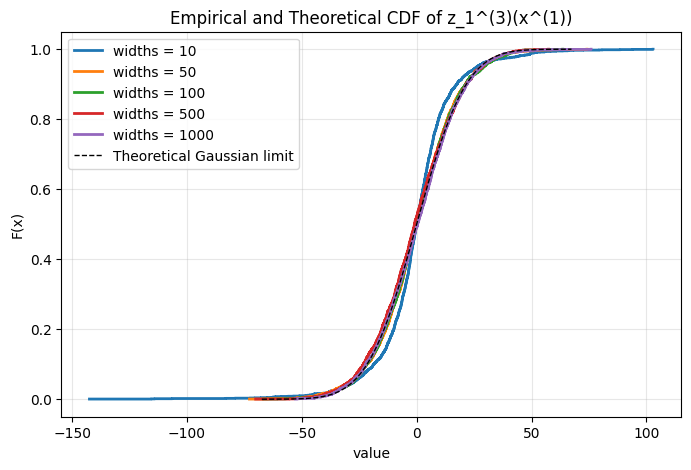

In [ ]:
# ------------------------------------------------
# EXAMPLE WITH I.I.D. VARIANCES: V_{n_l,j}=X_j/n_l
# ------------------------------------------------
# We generate THEORETICAL AND EMPIRICAL PDF, CDFs

X = np.array(
    [[0.2, -0.1, 0.4],
     [1.0,  0.3, 0.7],
     [-0.5, 0.8, 0.1],
     [0.9, -0.2, 0.6]], dtype=float)

p_list = [10, 50, 100, 500, 1000]

n_reps = 2000

rate=2
sample_V_iid_exp = make_sample_V_exp(rate)

a_list = [1/2,1/2]

C_B = 10
C_W = 15
L = 2
n_L_plus_1 = 1
# n0_val = X.shape[0]

rng = np.random.default_rng(42)

# 1. Collect Empirical Outputs
outputs_by_width = {}
for p in p_list:
    samples = np.zeros(n_reps, dtype=float)
    for r in range(n_reps):
        Z_final = simulate_one_network(
            X=X,
            L=L,
            C_B=C_B,
            C_W=C_W,
            widths=[int(p - (L - ell + 1) * 0.1) for ell in range(1, L + 1)],
            output_width=n_L_plus_1,
            sample_V=sample_V_iid_exp,
            sigma=relu,
            rng=rng
        )
        samples[r] = extract_scalar_output(Z_final, input_idx=0,output_idx=0)  # x^(1)
    outputs_by_width[p] = samples

# 2. Calculate Theoretical Kernel Limit (for Gaussian parameters)
K_avg_limit_theoretical_exp, _ = K_no_poisson(
    X=X,
    L=L,
    C_B=C_B,
    C_W=C_W,
    a_list=a_list,
    sigma=relu,
    n_mc=2000, # used for the Monte Carlo estimation of E[sigma(z)sigma(z)^T]
    jitter=1e-10
)


input_idx_for_plot = 0
gaussian_mean_for_plot = 0.0 # Assumption for network output mean
gaussian_std_for_plot = np.sqrt(K_avg_limit_theoretical_exp[input_idx_for_plot, input_idx_for_plot])



# plot empirical and theoretical CDFs

title_cdf = "Empirical and Theoretical CDF of z_1^(3)(x^(1))"

# Create the figure and axes for CDF
fig_cdf, ax_cdf = plt.subplots(figsize=(8, 5))

# Plot empirical CDFs
for p, vals in outputs_by_width.items():
    vals = np.sort(vals)
    cdf = np.arange(1, len(vals) + 1) / len(vals)
    ax_cdf.step(vals, cdf, where="post", linewidth=2, label=f"widths = {p}")

# Get theoretical Gaussian CDF data
x_gauss_cdf, _, cdf_gauss = get_gaussian_pdf_cdf_data(
    K=K_avg_limit_theoretical_exp,
    input_idx=input_idx_for_plot,
    mean=gaussian_mean_for_plot,
    num_std_devs=4,
    num_points=500,
)

# Overlay theoretical Gaussian CDF
ax_cdf.plot(x_gauss_cdf, cdf_gauss, 'k--', linewidth=1, label="Theoretical Gaussian limit")

ax_cdf.set_title(title_cdf)
ax_cdf.set_xlabel("value")
ax_cdf.set_ylabel("F(x)")
ax_cdf.grid(True, alpha=0.3)
ax_cdf.legend()
plt.show()

**SIMULATION 2**: functional CLT


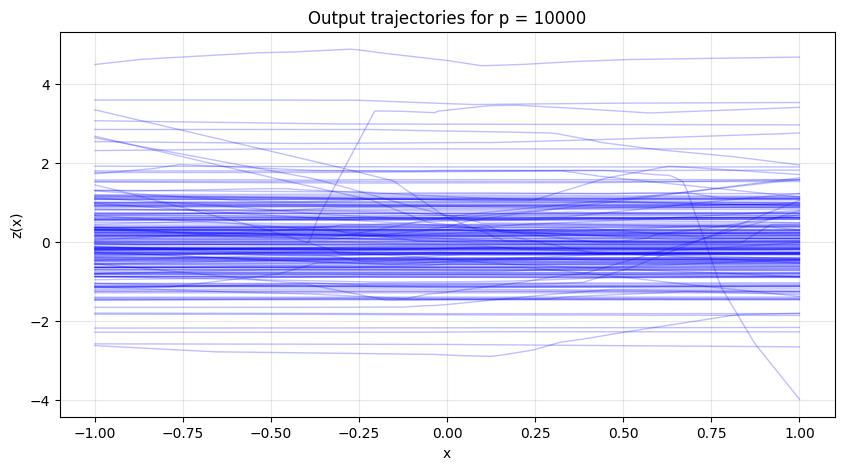

In [44]:
# output when p=10000, sigma=relu

x_grid = np.linspace(-1.0, 1.0, 200)

L = 5
C_B = 0.5
C_W = 5
n_L_plus_1 = 1

lam = 3
sample_V_gamma = make_sample_V_gamma_function(lam)

# plot of 1 only
p = 10000

trajectories = simulate_many_scalar_trajectories(
    x_grid=x_grid,
    N=200, # Number of trajectories to simulate
    L=L,
    widths=[int(p - (L - ell + 1) * 0.1) for ell in range(1, L + 1)],
    sample_V=sample_V_gamma,
    sigma=relu,
    C_B=C_B,
    C_W=C_W,
    master_seed=30
)

# plots
plt.figure(figsize=(10, 5))

for i in range(trajectories.shape[0]):
    plt.plot(x_grid, trajectories[i], linewidth=1, alpha=0.25, color='blue')

plt.xlabel("x")
plt.ylabel("z(x)")
plt.title(f"Output trajectories for p = {p}")
plt.grid(True, alpha=0.3)
plt.show()

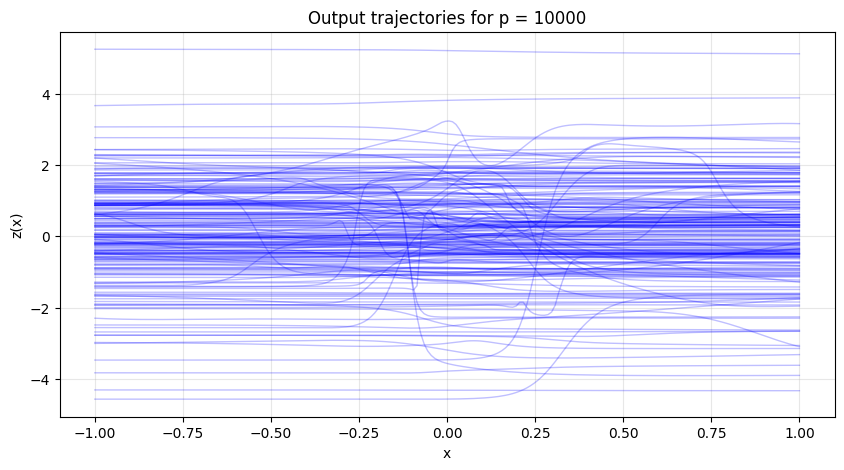

In [55]:
# output when p=10000, sigma=tanh

x_grid = np.linspace(-1.0, 1.0, 200)

L = 5
C_B = 0.5
C_W = 10
n_L_plus_1 = 1

lam = 3
sample_V_gamma = make_sample_V_gamma_function(lam)

# plot of 1 only
p = 10000

trajectories = simulate_many_scalar_trajectories(
    x_grid=x_grid[None, :],
    N=200, # Number of trajectories to simulate
    L=L,
    widths=[int(p - (L - ell ) * (0.1*p)) for ell in range(1, L+1)],
    sample_V=sample_V_gamma,
    sigma=np.tanh,
    C_B=C_B,
    C_W=C_W,
    master_seed=42
)

# plot
plt.figure(figsize=(10, 5))

for i in range(trajectories.shape[0]):
    plt.plot(x_grid, trajectories[i], linewidth=1, alpha=0.25, color='blue')

plt.xlabel("x")
plt.ylabel("z(x)")
plt.title(f"Output trajectories for p = {p}")
plt.grid(True, alpha=0.3)
plt.show()

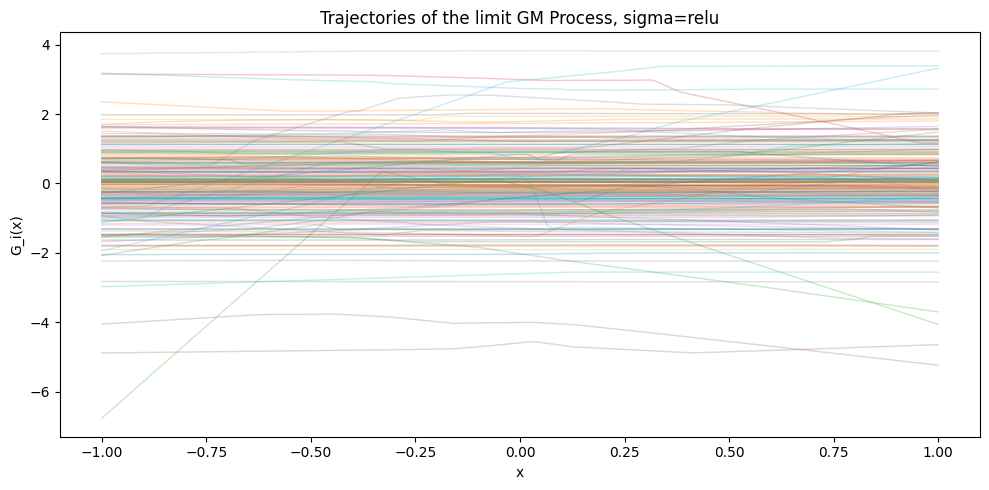

In [53]:
# SIMULATION 2  --> GP1 : sigma=relu
L=5
C_B = 0.5
C_W = 5

    # 1D time grid
times = np.linspace(-1, 1, 200)

# simulates many trajectories of the limit process
paths, kernels = sample_many_paths(
    M=200,
    times=times,
    X=times[None, :],   # in 1D: domain points as a row (see definition of recursive_kernel_gamma_levy)
    L=L,
    C_B=C_B,
    C_W=C_W,
    lam=lam,
    sigma=relu,
    eps=1e-5,
    jitter=1e-10,
    rng=np.random.default_rng(129) # 42 # 20,15 # 345,34   16, 56 big outlier  #123, 456 1234 medio
)


# trajectories plot
paths = np.asarray(paths)
times = np.asarray(times)

plt.figure(figsize=(10, 5))

for i in range(paths.shape[0]):
   plt.plot(times, paths[i], linewidth=1, alpha=0.25)

plt.xlabel("x")
plt.ylabel("G_i(x)")
plt.title("Trajectories of the limit GM Process, sigma=relu")
plt.tight_layout()
plt.show()

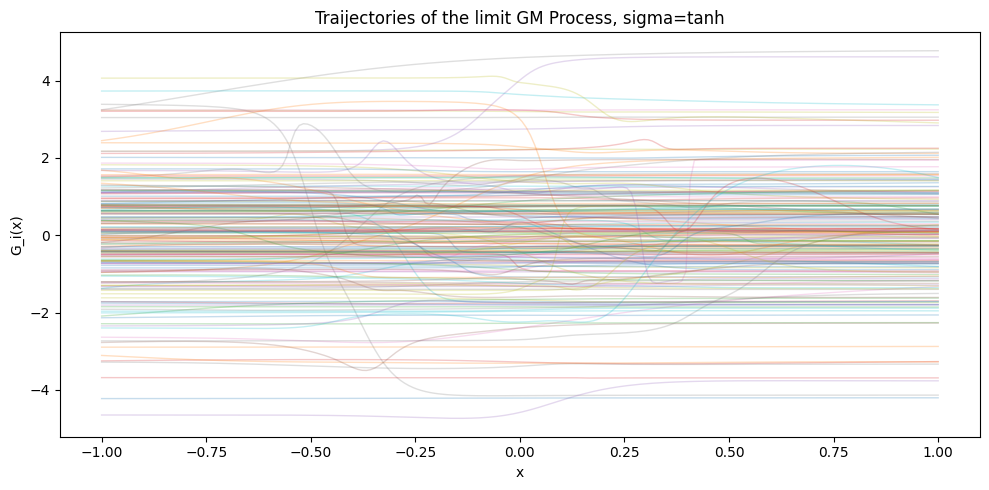

In [ ]:
# SIMULATION 2  --> GP2: sigma=tanh
L=5
C_B = 0.5
C_W = 10

# 1D time grid
times = np.linspace(-1, 1, 200)

# simulates many trajectories of the limit process
paths, kernels = sample_many_paths(
    M=200,
    times=times,
    X=times[None, :],   # in 1D: domain points as a row (see definition of recursive_kernel_gamma_levy)
    L=L,
    C_B=C_B,
    C_W=C_W,
    lam=lam,
    sigma=np.tanh,
    eps=1e-5,
    jitter=1e-10,
    rng=np.random.default_rng(12)
)

# trajectories plot
paths = np.asarray(paths)
times = np.asarray(times)

plt.figure(figsize=(10, 5))

for i in range(paths.shape[0]):
   plt.plot(times, paths[i], linewidth=1, alpha=0.25)

plt.xlabel("x")
plt.ylabel("G_i(x)")
plt.title("Trajectories of the limit GM Process, sigma=tanh")
plt.tight_layout()
plt.show()

**Simulation 3**

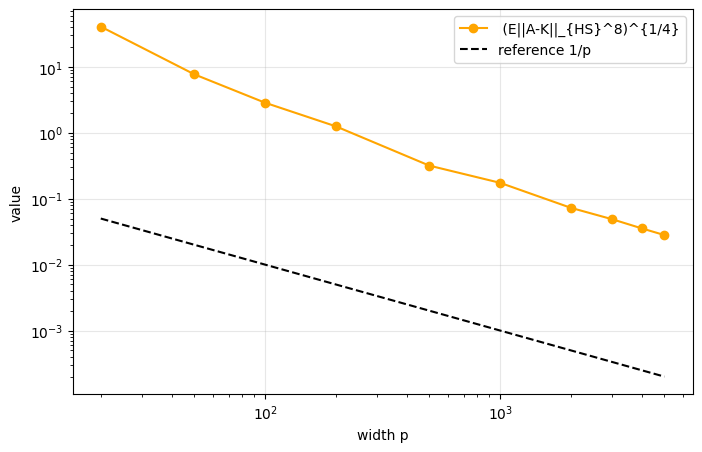

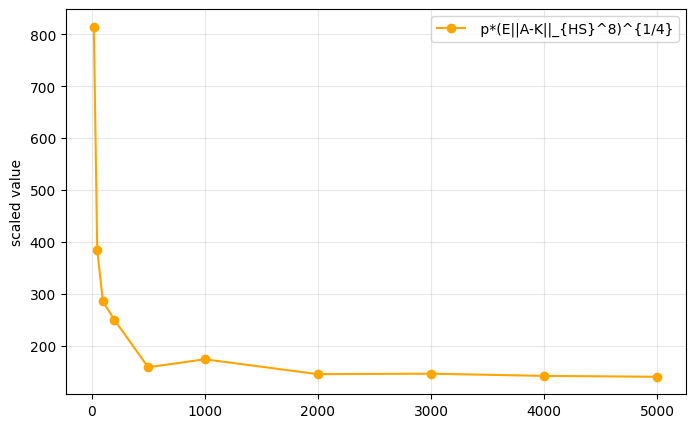

In [ ]:
# example 1 : sigma=relu
X = np.array(
    [[0.2, -0.1, 0.4],
     [1.0,  0.3, 0.7],
     [-0.5, 0.8, 0.1],
     [0.9, -0.2, 0.6]], dtype=float)

C_B = 1
C_W = 1
L=1
n_L_plus_1=5
n0=4
# increasing widths
widths_list = [20, 50, 100, 200, 500,1000,2000,3000,4000,5000]

# Example: variances ~ Exp(2) -> mean=1/2 -> a^1=a^1=1/2
a_list = L *[1/2]

K_true, results = estimate_hs_terms(
    X=X,
    widths_list=widths_list,
    L=L,
    C_B=C_B,
    C_W=C_W,
    sample_V=sample_V_iid_exp,
    a_list=a_list,
    sigma=relu,
    A_L_plus_1=A_L_plus_1,
    K_no_poisson=K_no_poisson,
    n_reps=20000,     # Number of networks for each p
    n_mc_K=2000000,
    jitter_K=1e-12,
    output_width=n_L_plus_1,
    seed=42
)

# plots

p_vals = np.array(widths_list, dtype=float)
term2_vals = np.array([results[p]["term2"] for p in widths_list])

# 1) log-log
plt.figure(figsize=(8, 5))
plt.loglog(p_vals, term2_vals, 'o-', color='orange', label=r' (E||A-K||_{HS}^8)^{1/4}')
plt.loglog(p_vals, 1.0 / p_vals, 'k--', label=r'reference 1/p')
plt.xlabel("width p")
plt.ylabel("value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 2) p * quantity: if it goes as 1/p, this should stabilize

# graph 2: term2
plt.figure(figsize=(8, 5))
plt.plot(p_vals, p_vals * term2_vals, 'o-', color='orange', label=r' p*(E||A-K||_{HS}^8)^{1/4}')
plt.ylabel("scaled value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

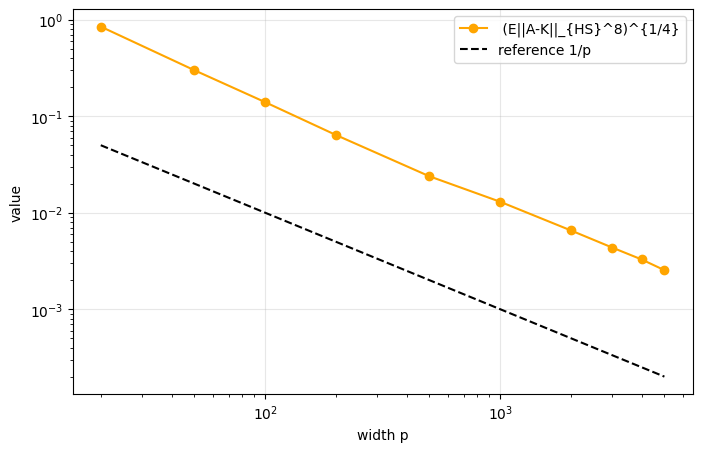

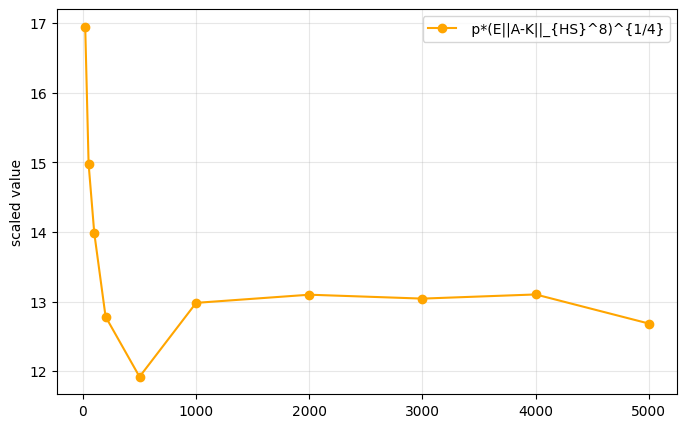

In [ ]:
# example 2: sigma=tanh
X = np.array(
    [[0.2, -0.1, 0.4],
     [1.0,  0.3, 0.7],
     [-0.5, 0.8, 0.1],
     [0.9, -0.2, 0.6]], dtype=float)

C_B = 1
C_W = 1
L=1
n_L_plus_1=5
n0=4
# increasing widths
widths_list = [20, 50, 100, 200, 500,1000,2000,3000,4000,5000]

# Example: variances ~ Exp(2) -> mean=1/2 -> a^1=a^1=1/2
a_list = L *[1/2]

K_true, results = estimate_hs_terms(
    X=X,
    widths_list=widths_list,
    L=L,
    C_B=C_B,
    C_W=C_W,
    sample_V=sample_V_iid_exp,
    a_list=a_list,
    sigma=np.tanh,
    A_L_plus_1=A_L_plus_1,
    K_no_poisson=K_no_poisson,
    n_reps=20000,     # Number of networks for each p
    n_mc_K=2000000,
    jitter_K=1e-12,
    output_width=n_L_plus_1,
    seed=42
)

# plots

p_vals = np.array(widths_list, dtype=float)
term2_vals = np.array([results[p]["term2"] for p in widths_list])

# 1) log-log
plt.figure(figsize=(8, 5))
plt.loglog(p_vals, term2_vals, 'o-', color='orange', label=r' (E||A-K||_{HS}^8)^{1/4}')
plt.loglog(p_vals, 1.0 / p_vals, 'k--', label=r'reference 1/p')
plt.xlabel("width p")
plt.ylabel("value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 2) p * quantity: if it goes as 1/p, this should stabilize

# graph 2: term2
plt.figure(figsize=(8, 5))
plt.plot(p_vals, p_vals * term2_vals, 'o-', color='orange', label=r' p*(E||A-K||_{HS}^8)^{1/4}')
plt.ylabel("scaled value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()